# AI Supply Chain Risk Intelligence Platform
## New Bagging & Boosting Algorithms + Final Model Comparison

### Purpose of this notebook

Your **Linear Regression** and **Decision Tree Regression** models were already implemented in earlier notebooks, so this notebook does **not** repeat those algorithms.

This notebook implements only the **new ensemble regression algorithms**:

### Bagging family
- Bagging Regressor
- Random Forest Regressor
- Extra Trees Regressor

### Boosting family
- AdaBoost Regressor
- Gradient Boosting Regressor
- HistGradientBoosting Regressor
- XGBoost Regressor *(if installed)*
- LightGBM Regressor *(if installed)*
- CatBoost Regressor *(if installed)*

All new models use the same:
- target: `shipping_delay_days`
- feature set
- chronological 80/20 train-test split
- preprocessing strategy

At the end, you can enter the test results from your **existing Linear Regression and Decision Tree notebooks**, and this notebook combines them with the new ensemble results in one final comparison table.

### Evaluation metrics
- MAE
- RMSE
- R²
- Train R²
- Test R²
- R² generalization gap
- Training time


## 1. Import Libraries

In [3]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42


## 2. Optional Boosting Libraries

XGBoost, LightGBM, and CatBoost are popular boosting libraries but are not part of the core scikit-learn installation.

The notebook checks whether they are installed. If one is missing, that model is simply skipped instead of stopping the whole notebook.

If needed, install them in your terminal:

```bash
pip install xgboost lightgbm catboost
```


In [5]:
AVAILABLE_OPTIONAL_MODELS = {}

try:
    from xgboost import XGBRegressor
    AVAILABLE_OPTIONAL_MODELS["XGBoost"] = True
    print("XGBoost: available")
except ImportError:
    AVAILABLE_OPTIONAL_MODELS["XGBoost"] = False
    print("XGBoost: not installed - model will be skipped")

try:
    from lightgbm import LGBMRegressor
    AVAILABLE_OPTIONAL_MODELS["LightGBM"] = True
    print("LightGBM: available")
except ImportError:
    AVAILABLE_OPTIONAL_MODELS["LightGBM"] = False
    print("LightGBM: not installed - model will be skipped")

try:
    from catboost import CatBoostRegressor
    AVAILABLE_OPTIONAL_MODELS["CatBoost"] = True
    print("CatBoost: available")
except ImportError:
    AVAILABLE_OPTIONAL_MODELS["CatBoost"] = False
    print("CatBoost: not installed - model will be skipped")


XGBoost: available
LightGBM: not installed - model will be skipped
CatBoost: not installed - model will be skipped


## 3. Load the Processed Supply-Chain Dataset

In [7]:
def find_processed_file():
    possible_paths = [
        Path.cwd() / "data" / "processed" / "supply_chain_ml_ready.csv",
        Path.cwd().parent / "data" / "processed" / "supply_chain_ml_ready.csv",
        Path("/mnt/data/data/processed/supply_chain_ml_ready.csv"),
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find supply_chain_ml_ready.csv. "
        "Place it in data/processed/ or change the path above."
    )


DATA_PATH = find_processed_file()

print("Using dataset:", DATA_PATH.resolve())

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"],
)

# Sort chronologically because we want to train on older observations
# and evaluate on newer/future observations.
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())


Using dataset: C:\Users\bunny\Downloads\data\processed\supply_chain_ml_ready.csv
Dataset shape: (31300, 57)


,date,route_id,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,container_availability_index,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,geopolitical_risk_score,route_status,carbon_emissions_tonnes,oil_price,natural_gas_price,steel_price,wheat_price,copper_price,commodity_stress_index,origin_country,destination_country,distance_km,shipping_method,trade_route_type,estimated_transit_days,origin_iso3,origin_region,origin_income_group,origin_population,origin_gdp_per_capita,origin_trade_dependency_score,origin_port_capacity_index,origin_logistics_performance_index,destination_iso3,destination_region,destination_income_group,destination_population,destination_gdp_per_capita,destination_trade_dependency_score,destination_port_capacity_index,destination_logistics_performance_index,year,quarter,month,week_of_year,freight_cost_per_tonne,freight_cost_per_km,emissions_per_tonne,emissions_per_km,planned_km_per_day,average_logistics_performance,average_port_capacity,logistics_performance_gap,port_capacity_gap,gdp_per_capita_gap,operational_risk_score,delay_category
0,2015-01-04,R00001,"8,418.6900",7.5500,"4,586.6600",71.4200,82.2200,62.4800,19.2000,59.5100,57.1500,Delayed,"3,681.4900",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,India,United States,"8,746.0000",Rail,Consumer Goods,19.0000,IND,South Asia,High income,430389014,60735,23.7300,56.0400,86.6600,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,2015,1,1,1,0.5448,0.5244,0.4373,0.4209,460.3158,60.2650,38.5500,52.7900,34.9800,3220,56.3420,High (5-10)
1,2015-01-04,R00023,"20,172.8200",9.5100,"4,967.0400",67.0500,19.3200,62.4800,19.2000,68.1000,65.8900,Delayed,"9,681.9500",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United States,Japan,"9,599.0000",Air,Consumer Goods,45.0000,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,JPN,East Asia & Pacific,Upper middle income,435285667,68969,27.2500,65.0600,34.5800,2015,1,1,1,0.2462,0.5175,0.4800,1.0086,213.3111,34.2250,43.0600,0.7100,44.0000,5014,44.7385,High (5-10)
2,2015-01-04,R00022,"4,216.5800",10.7900,"3,345.4100",54.9200,72.5200,62.4800,19.2000,89.9700,90.1500,Delayed,"1,155.5500",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United Kingdom,India,"5,481.0000",Sea,Consumer Goods,36.0000,GBR,Europe & Central Asia,Low income,894664919,54707,50.6000,21.2800,54.0100,IND,South Asia,High income,430389014,60735,23.7300,56.0400,86.6600,2015,1,1,1,0.7934,0.6104,0.2740,0.2108,152.2500,70.3350,38.6600,32.6500,34.7600,6028,69.0840,Severe (>10)
3,2015-01-04,R00021,"34,119.2300",2.6700,"3,884.7100",74.0600,44.4100,62.4800,19.2000,39.1200,51.8700,Normal,"12,342.6300",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,United States,United Kingdom,"7,235.0000",Rail,Manufacturing,3.0000,USA,North America,Low income,250467210,63955,97.9000,21.0600,33.8700,GBR,Europe & Central Asia,Low income,894664919,54707,50.6000,21.2800,54.0100,2015,1,1,1,0.1139,0.5369,0.3617,1.7060,"2,411.6659",43.9400,21.1700,20.1400,0.2200,9248,41.3595,Moderate (2-5)
4,2015-01-04,R00020,"19,754.8100",9.1900,"5,017.8800",55.1300,17.5600,62.4800,19.2000,33.0400,89.7400,Delayed,"9,622.5700",62.4836,2.5052,500.3132,186.3312,"6,674.4548",19.2000,France,Japan,"9,742.0000",Air,Manufacturing,3.0000,FRA,Europe & Central Asia,Low income,649061058,29693,98.6600,38.4700,36.6400,JPN,East Asia & Pacific,Upper middle income,435285667,68969,27.2500,65.0600,34.5800,2015,1,1,1,0.2540,0.5151,0.4871,0.9877,"3,247.3323",35.6100,51.7650,2.0600,26.5900,39276,43.8445,High (5-10)


## 4. Target and Leakage Control

Target:

```python
shipping_delay_days
```

We remove `container_shortage_score` because the original Decision Tree notebook treated it as redundant with `container_availability_index`.

We also deliberately exclude outcome-derived columns such as `delay_category` and `route_status` from the model features.


In [9]:
TARGET = "shipping_delay_days"

df.drop(
    columns=["container_shortage_score"],
    inplace=True,
    errors="ignore",
)

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' was not found.")

print("Target:", TARGET)


Target: shipping_delay_days


## 5. Select the Same Project Features

In [11]:
numeric_features = [
    "trade_volume_tonnes",
    "freight_cost_per_tonne",
    "container_availability_index",
    "port_congestion_index",
    "fuel_cost_index",
    "commodity_stress_index",
    "weather_disruption_score",
    "geopolitical_risk_score",
    "distance_km",
    "estimated_transit_days",
    "month",
]

categorical_features = [
    "shipping_method",
    "trade_route_type",
]

model_features = numeric_features + categorical_features

missing_features = [
    col for col in model_features
    if col not in df.columns
]

if missing_features:
    raise KeyError(
        "These required model features are missing: "
        + ", ".join(missing_features)
    )

X = df[model_features].copy()
y = df[TARGET].copy()

print("Number of original input features:", len(model_features))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Target:", TARGET)

display(X.head())


Number of original input features: 13
Numeric features: 11
Categorical features: 2
Target: shipping_delay_days


,trade_volume_tonnes,freight_cost_per_tonne,container_availability_index,port_congestion_index,fuel_cost_index,commodity_stress_index,weather_disruption_score,geopolitical_risk_score,distance_km,estimated_transit_days,month,shipping_method,trade_route_type
0,"8,418.6900",0.5448,71.4200,82.2200,62.4800,19.2000,59.5100,57.1500,"8,746.0000",19.0000,1,Rail,Consumer Goods
1,"20,172.8200",0.2462,67.0500,19.3200,62.4800,19.2000,68.1000,65.8900,"9,599.0000",45.0000,1,Air,Consumer Goods
2,"4,216.5800",0.7934,54.9200,72.5200,62.4800,19.2000,89.9700,90.1500,"5,481.0000",36.0000,1,Sea,Consumer Goods
3,"34,119.2300",0.1139,74.0600,44.4100,62.4800,19.2000,39.1200,51.8700,"7,235.0000",3.0000,1,Rail,Manufacturing
4,"19,754.8100",0.2540,55.1300,17.5600,62.4800,19.2000,33.0400,89.7400,"9,742.0000",3.0000,1,Air,Manufacturing


## 6. Time-Based 80/20 Train-Test Split

A random split can mix future information into the training data.

For a forecasting-style supply-chain problem, a chronological split is more realistic:

- First 80% → training
- Last 20% → testing


In [13]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = df["date"].iloc[:split_index]
test_dates = df["date"].iloc[split_index:]

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")
print(
    f"Training period: {train_dates.min().date()} "
    f"to {train_dates.max().date()}"
)
print(
    f"Testing period : {test_dates.min().date()} "
    f"to {test_dates.max().date()}"
)


Training rows: 25,040
Testing rows : 6,260
Training period: 2015-01-04 to 2024-08-04
Testing period : 2024-08-04 to 2026-12-27


## 7. Preprocessing

Tree-based ensemble models do **not** require feature standardization.

Numeric features are passed through unchanged.

Categorical features are converted to numeric dummy variables using `OneHotEncoder`.


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)


# PART B — Bagging Algorithms

Bagging means **Bootstrap Aggregating**.

The basic idea is:

1. Create multiple samples from the training data.
2. Train many models independently.
3. Combine their predictions, usually by averaging.

Bagging mainly helps reduce **variance**.

For this project, that can make delay predictions more stable than relying on one Decision Tree.


## 9. Bagging Regressor

`BaggingRegressor` trains many base estimators on different bootstrap samples.

Here, each base estimator is a Decision Tree.


In [18]:
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    n_estimators=100,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 10. Random Forest Regressor

Random Forest is a specialized bagging method.

It adds extra randomness by:
- training many Decision Trees on bootstrap samples;
- allowing each split to consider only a random subset of features.

This reduces correlation between trees and often improves generalization.


In [20]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 11. Extra Trees Regressor

Extra Trees is similar to Random Forest but introduces even more randomness when choosing split thresholds.

That often makes it:
- fast,
- resistant to overfitting,
- useful for nonlinear tabular data.


In [22]:
extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


# PART C — Boosting Algorithms

Boosting builds models **sequentially**.

Instead of training independent trees, each new learner tries to improve the mistakes made by the previous learners.

Boosting can reduce both bias and prediction error, but aggressive settings can overfit.


## 12. AdaBoost Regressor

AdaBoost gives more attention to observations that previous weak learners predicted poorly.

We use shallow Decision Trees as the weak learners.


In [25]:
adaboost_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    n_estimators=200,
    learning_rate=0.05,
    loss="linear",
    random_state=RANDOM_STATE,
)


## 13. Gradient Boosting Regressor

Gradient Boosting builds small trees sequentially.

Each new tree is trained to reduce the residual errors from the current ensemble.


In [27]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    loss="squared_error",
    random_state=RANDOM_STATE,
)


## 14. Histogram Gradient Boosting

`HistGradientBoostingRegressor` groups continuous values into bins before searching for splits.

It is designed to be efficient on larger tabular datasets.


In [29]:
hist_gradient_boosting_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)


## 15. XGBoost

XGBoost is an optimized gradient-boosted tree implementation.

Important controls include:
- `n_estimators` → number of trees
- `learning_rate` → contribution from each tree
- `max_depth` → complexity of each tree
- `subsample` → fraction of rows sampled for each tree
- `colsample_bytree` → fraction of features sampled for each tree
- `reg_alpha` / `reg_lambda` → regularization


In [31]:
xgboost_model = None

if AVAILABLE_OPTIONAL_MODELS["XGBoost"]:
    xgboost_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


## 16. LightGBM

LightGBM is another gradient-boosted tree implementation designed for efficient training.

Its leaf-wise tree growth can produce strong results on structured/tabular datasets.


In [33]:
lightgbm_model = None

if AVAILABLE_OPTIONAL_MODELS["LightGBM"]:
    lightgbm_model = LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )


## 17. CatBoost

CatBoost is a gradient boosting library especially well known for handling structured data.

In this notebook we still use the same one-hot preprocessing as every other model so the comparison stays consistent.


In [35]:
catboost_model = None

if AVAILABLE_OPTIONAL_MODELS["CatBoost"]:
    catboost_model = CatBoostRegressor(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )


## Create One Common Model Dictionary

Each **new ensemble estimator** is wrapped in the same preprocessing pipeline.

This ensures that Bagging, Random Forest, Extra Trees, AdaBoost, Gradient Boosting, HistGradientBoosting, XGBoost, LightGBM, and CatBoost are trained under the same conditions.


In [37]:
models = {
    "Bagging": bagging_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boosting_model,
    "HistGradientBoosting": hist_gradient_boosting_model,
}

if xgboost_model is not None:
    models["XGBoost"] = xgboost_model

if lightgbm_model is not None:
    models["LightGBM"] = lightgbm_model

if catboost_model is not None:
    models["CatBoost"] = catboost_model

print("NEW ensemble models that will be trained:")
for name in models:
    print("-", name)


NEW ensemble models that will be trained:
- Bagging
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- HistGradientBoosting
- XGBoost


## 19. Evaluation Function

We will calculate:

### MAE
Average absolute difference between actual and predicted delay days.

### RMSE
Penalizes larger prediction errors more heavily.

### R²
Measures how much of the variation in shipping delay is explained by the model.

### Generalization Gap
`Train R² - Test R²`

A very large positive gap can indicate overfitting.


In [39]:
def evaluate_regression_model(
    model_name,
    estimator,
    X_train,
    y_train,
    X_test,
    y_test,
):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    start_time = time.perf_counter()

    pipeline.fit(X_train, y_train)

    training_seconds = time.perf_counter() - start_time

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_predictions)
    )
    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_predictions)
    )

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    result = {
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2,
        "Training Seconds": training_seconds,
    }

    return result, pipeline, test_predictions


## 20. Train All Models

In [41]:
results = []
fitted_models = {}
test_predictions_by_model = {}

for model_name, estimator in models.items():
    print("=" * 70)
    print("Training:", model_name)

    try:
        result, fitted_pipeline, predictions = evaluate_regression_model(
            model_name=model_name,
            estimator=estimator,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
        )

        results.append(result)
        fitted_models[model_name] = fitted_pipeline
        test_predictions_by_model[model_name] = predictions

        print(
            f"Test MAE={result['Test MAE']:.4f} | "
            f"Test RMSE={result['Test RMSE']:.4f} | "
            f"Test R²={result['Test R²']:.4f}"
        )

    except Exception as exc:
        print(f"{model_name} failed and was skipped.")
        print("Reason:", exc)


Training: Bagging
Test MAE=1.8133 | Test RMSE=2.3210 | Test R²=0.4869
Training: Random Forest
Test MAE=1.8262 | Test RMSE=2.3410 | Test R²=0.4780
Training: Extra Trees
Test MAE=1.8363 | Test RMSE=2.3512 | Test R²=0.4734
Training: AdaBoost
Test MAE=1.8513 | Test RMSE=2.3703 | Test R²=0.4648
Training: Gradient Boosting
Test MAE=1.8062 | Test RMSE=2.3228 | Test R²=0.4861
Training: HistGradientBoosting
Test MAE=1.8168 | Test RMSE=2.3350 | Test R²=0.4807
Training: XGBoost
Test MAE=1.7748 | Test RMSE=2.2698 | Test R²=0.5093


## 21. Final Model Comparison Table

The table is sorted by **Test RMSE**, from lowest to highest.

The first row is therefore the strongest model according to RMSE.


In [43]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test RMSE",
    ascending=True,
).reset_index(drop=True)

results_df.insert(
    0,
    "Rank",
    np.arange(1, len(results_df) + 1),
)

display(results_df)


,Rank,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap,Training Seconds
0,1,XGBoost,1.4284,1.7748,1.7893,2.2698,0.6142,0.5093,0.1049,1.2584
1,2,Bagging,1.3764,1.8133,1.7217,2.3210,0.6428,0.4869,0.1559,11.8948
2,3,Gradient Boosting,1.5478,1.8062,1.9344,2.3228,0.5491,0.4861,0.0630,28.8028
3,4,HistGradientBoosting,1.5130,1.8168,1.8904,2.3350,0.5693,0.4807,0.0887,2.3603
4,5,Random Forest,1.1567,1.8262,1.4611,2.3410,0.7427,0.4780,0.2647,6.8036
5,6,Extra Trees,1.0411,1.8363,1.3117,2.3512,0.7926,0.4734,0.3192,5.4357
6,7,AdaBoost,1.6260,1.8513,2.0215,2.3703,0.5075,0.4648,0.0427,22.1106


# Final Comparison — Previous + New Regression Models

Your previous notebooks already contain the Linear Regression family and Decision Tree work, so those algorithms are **not trained again** here.

For a fair final regression comparison, this notebook carries forward:

- **Ridge Regression** — the best linear-family model in your Linear Regression notebook
- **Tuned Decision Tree** — the improved Decision Tree from your Decision Tree notebook

The new Bagging and Boosting models trained in this notebook are then added automatically.

The final regression ranking therefore compares the best earlier regression models with:

- Bagging
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- HistGradientBoosting
- XGBoost (when installed)
- LightGBM (when installed)
- CatBoost (when installed)

### Why Logistic Regression is not placed in the same RMSE/R² ranking

Your Logistic Regression notebook solves a **different target**:

`high_delay_flag` = whether shipping delay is **7 days or more**.

It is a classification model and uses Accuracy, Precision, Recall, F1, Specificity and ROC-AUC. Those metrics cannot be directly ranked against regression MAE/RMSE/R².

A separate Logistic Regression summary is included later in this notebook.


In [45]:
# ============================================================
# RESULTS FROM YOUR ALREADY-EXECUTED REGRESSION NOTEBOOKS
# ============================================================
# These values were taken from your uploaded notebooks.
#
# Linear notebook:
#   Best linear-family model = Ridge Regression
# Decision Tree notebook:
#   Best tree model = Tuned Decision Tree
#
# We use the BEST properly-generalizing version from each earlier notebook
# for the final project model comparison.

existing_model_results = pd.DataFrame([
    {
        "Model": "Ridge Regression (Best Linear)",
        "Train MAE": 1.5905,
        "Test MAE": 1.8025,
        "Train RMSE": 1.9886,
        "Test RMSE": 2.3161,
        "Train R²": 0.5234,
        "Test R²": 0.4890,
        "R² Gap": 0.0344,
        "Training Seconds": np.nan,
    },
    {
        "Model": "Tuned Decision Tree",
        "Train MAE": 1.5842,
        "Test MAE": 1.8676,
        "Train RMSE": 1.9808,
        "Test RMSE": 2.3960,
        "Train R²": 0.5272,
        "Test R²": 0.4532,
        "R² Gap": 0.0740,
        "Training Seconds": np.nan,
    },
])

print("Existing regression results imported from your previous notebooks:")
display(existing_model_results)


Existing regression results imported from your previous notebooks:


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap,Training Seconds
0,Ridge Regression (Best Linear),1.5905,1.8025,1.9886,2.3161,0.5234,0.4890,0.0344,NaN
1,Tuned Decision Tree,1.5842,1.8676,1.9808,2.3960,0.5272,0.4532,0.0740,NaN


In [46]:
# ============================================================
# COMBINE EXISTING + NEW MODEL RESULTS
# ============================================================

all_model_results = pd.concat(
    [
        existing_model_results,
        results_df.drop(columns=["Rank"], errors="ignore"),
    ],
    ignore_index=True,
)

# Rank only models that have a valid Test RMSE.
rankable = all_model_results[
    all_model_results["Test RMSE"].notna()
].copy()

rankable = rankable.sort_values(
    "Test RMSE",
    ascending=True,
).reset_index(drop=True)

rankable.insert(
    0,
    "Rank",
    np.arange(1, len(rankable) + 1),
)

print("FINAL COMPARISON: ALL AVAILABLE MODELS")
display(rankable)


FINAL COMPARISON: ALL AVAILABLE MODELS


,Rank,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap,Training Seconds
0,1,XGBoost,1.4284,1.7748,1.7893,2.2698,0.6142,0.5093,0.1049,1.2584
1,2,Ridge Regression (Best Linear),1.5905,1.8025,1.9886,2.3161,0.5234,0.4890,0.0344,NaN
2,3,Bagging,1.3764,1.8133,1.7217,2.3210,0.6428,0.4869,0.1559,11.8948
3,4,Gradient Boosting,1.5478,1.8062,1.9344,2.3228,0.5491,0.4861,0.0630,28.8028
4,5,HistGradientBoosting,1.5130,1.8168,1.8904,2.3350,0.5693,0.4807,0.0887,2.3603
5,6,Random Forest,1.1567,1.8262,1.4611,2.3410,0.7427,0.4780,0.2647,6.8036
6,7,Extra Trees,1.0411,1.8363,1.3117,2.3512,0.7926,0.4734,0.3192,5.4357
7,8,AdaBoost,1.6260,1.8513,2.0215,2.3703,0.5075,0.4648,0.0427,22.1106
8,9,Tuned Decision Tree,1.5842,1.8676,1.9808,2.3960,0.5272,0.4532,0.0740,NaN


In [47]:
# ============================================================
# BEST MODEL ACROSS ALL AVAILABLE RESULTS
# ============================================================

if len(rankable) > 0:
    final_best = rankable.iloc[0]

    print("BEST MODEL ACROSS ALL AVAILABLE MODELS")
    print("---------------------------------------")
    print("Model    :", final_best["Model"])
    print(f"Test MAE : {final_best['Test MAE']:.4f}")
    print(f"Test RMSE: {final_best['Test RMSE']:.4f}")
    print(f"Test R²  : {final_best['Test R²']:.4f}")
    print(f"R² Gap   : {final_best['R² Gap']:.4f}")
else:
    print("No valid model results are available yet.")


BEST MODEL ACROSS ALL AVAILABLE MODELS
---------------------------------------
Model    : XGBoost
Test MAE : 1.7748
Test RMSE: 2.2698
Test R²  : 0.5093
R² Gap   : 0.1049


## Final Regression Model Interpretation

The table above is the **main final model-comparison result** for predicting exact shipping delay days.

Use this order when selecting the production model:

1. Lowest **Test RMSE**
2. Lowest **Test MAE**
3. Highest **Test R²**
4. Check the **R² Gap** to make sure the model is not strongly overfitting

The model ranked #1 is the best-performing regression model on the future test period.


In [49]:
# ============================================================
# AUTOMATIC BUSINESS INTERPRETATION OF FINAL REGRESSION RESULTS
# ============================================================

if len(rankable) > 0:
    winner = rankable.iloc[0]

    print("FINAL PROJECT MODEL SELECTION")
    print("=" * 60)
    print(f"Best regression model : {winner['Model']}")
    print(f"Test MAE              : {winner['Test MAE']:.4f} days")
    print(f"Test RMSE             : {winner['Test RMSE']:.4f} days")
    print(f"Test R²               : {winner['Test R²']:.4f}")
    print(f"Train-Test R² Gap     : {winner['R² Gap']:.4f}")
    print()

    if winner["R² Gap"] > 0.20:
        print("Warning: The model shows a relatively large train-test gap.")
        print("Check for overfitting before production use.")
    else:
        print("The train-test gap is reasonably controlled.")

    print()
    print(
        "Interpretation: Based on the common future test period, "
        f"{winner['Model']} currently gives the strongest overall "
        "shipping-delay regression performance among the compared models."
    )


FINAL PROJECT MODEL SELECTION
Best regression model : XGBoost
Test MAE              : 1.7748 days
Test RMSE             : 2.2698 days
Test R²               : 0.5093
Train-Test R² Gap     : 0.1049

The train-test gap is reasonably controlled.

Interpretation: Based on the common future test period, XGBoost currently gives the strongest overall shipping-delay regression performance among the compared models.


# Logistic Regression — Separate Classification Result

Your Logistic Regression notebook asks a different business question:

> **Will the shipment have a high delay of 7 days or more?**

Target:

`high_delay_flag`

- `0` = Lower Delay Risk
- `1` = High Delay Risk

Because this is classification, evaluate it separately using:

- Accuracy
- Precision
- Recall / Sensitivity
- Specificity
- F1 Score
- ROC-AUC

Do **not** compare Logistic Regression's Accuracy/F1 directly with Random Forest/XGBoost regression RMSE or R².

Your uploaded Logistic Regression notebook contains the code to calculate both default and tuned Logistic Regression metrics, but its saved notebook does not contain executed metric outputs. Therefore, this notebook does not invent those values.


# Final Project Model Structure

Your project now has **two related ML tasks**:

### 1. Regression — exact delay prediction

**Question:** How many days will this shipment be delayed?

Models compared:
- Ridge Regression
- Tuned Decision Tree
- Bagging
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- HistGradientBoosting
- XGBoost
- LightGBM
- CatBoost

The final regression comparison automatically selects the strongest model using unseen test-period performance.

### 2. Classification — high-delay risk

**Question:** Is this shipment likely to experience a delay of 7 days or more?

Model:
- Logistic Regression

This separation is important because regression and classification solve different business problems and use different evaluation metrics.


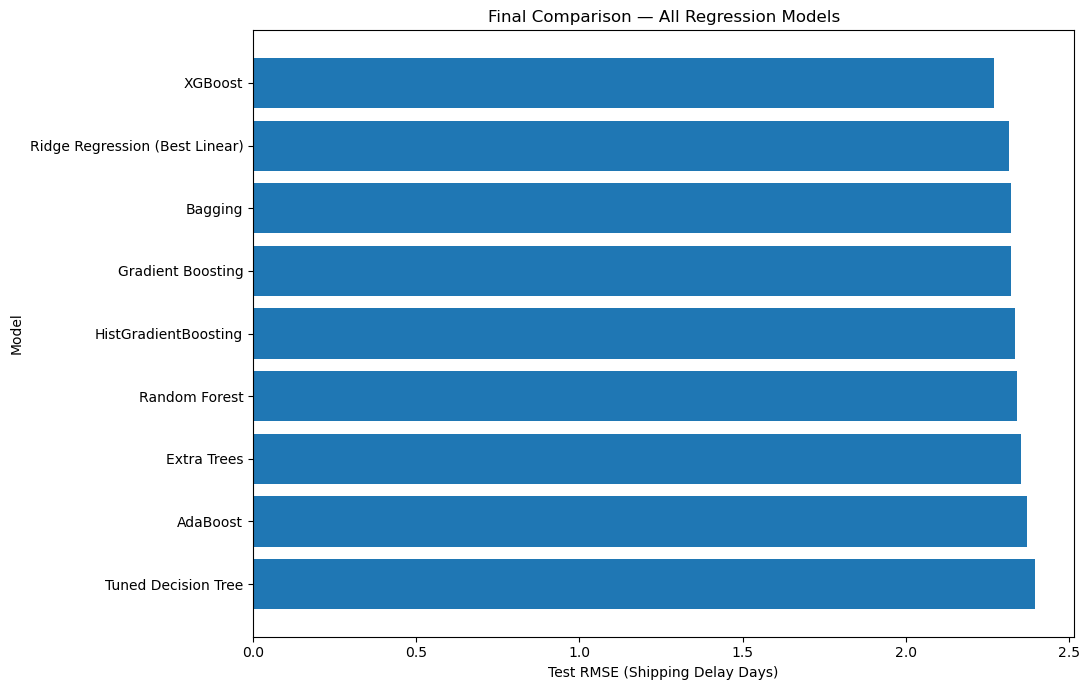

In [52]:
# ============================================================
# FINAL TEST RMSE COMPARISON
# ============================================================

if len(rankable) > 0:
    plot_df = rankable.sort_values(
        "Test RMSE",
        ascending=True,
    )

    plt.figure(figsize=(11, 7))
    plt.barh(
        plot_df["Model"],
        plot_df["Test RMSE"],
    )

    plt.xlabel("Test RMSE (Shipping Delay Days)")
    plt.ylabel("Model")
    plt.title("Final Comparison — All Regression Models")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


## 22. Automatically Select the Best Model

In [54]:
best_row = results_df.iloc[0]

BEST_MODEL_NAME = best_row["Model"]
best_model = fitted_models[BEST_MODEL_NAME]
best_predictions = test_predictions_by_model[BEST_MODEL_NAME]

print("BEST MODEL:", BEST_MODEL_NAME)
print(f"Test MAE : {best_row['Test MAE']:.4f}")
print(f"Test RMSE: {best_row['Test RMSE']:.4f}")
print(f"Test R²  : {best_row['Test R²']:.4f}")
print(f"R² Gap   : {best_row['R² Gap']:.4f}")


BEST MODEL: XGBoost
Test MAE : 1.7748
Test RMSE: 2.2698
Test R²  : 0.5093
R² Gap   : 0.1049


# PART E — Visual Comparison

## 23. Test RMSE by Model

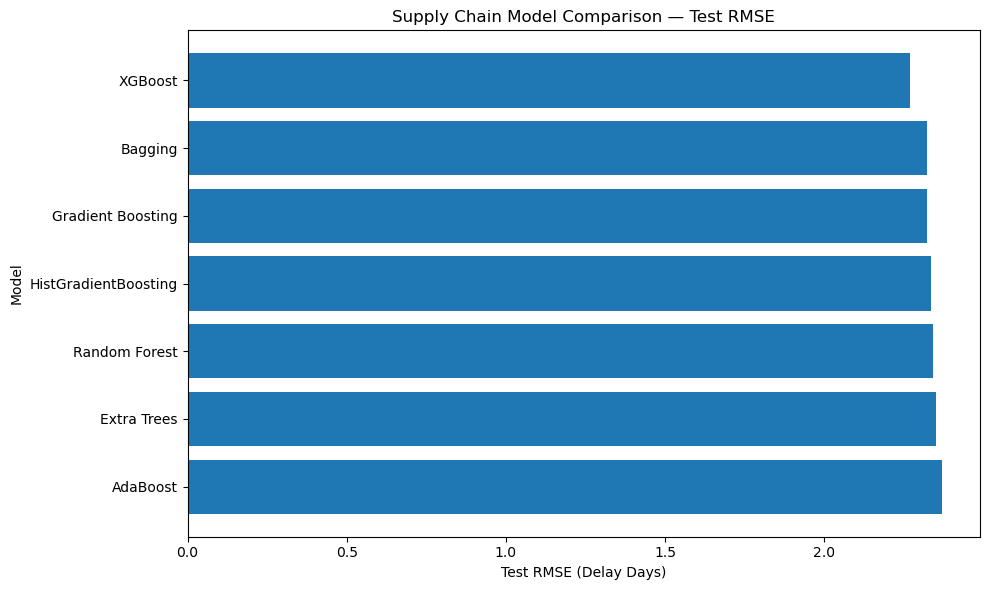

In [57]:
plot_df = results_df.sort_values(
    "Test RMSE",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Model"],
    plot_df["Test RMSE"],
)

plt.xlabel("Test RMSE (Delay Days)")
plt.ylabel("Model")
plt.title("Supply Chain Model Comparison — Test RMSE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 24. Test MAE by Model

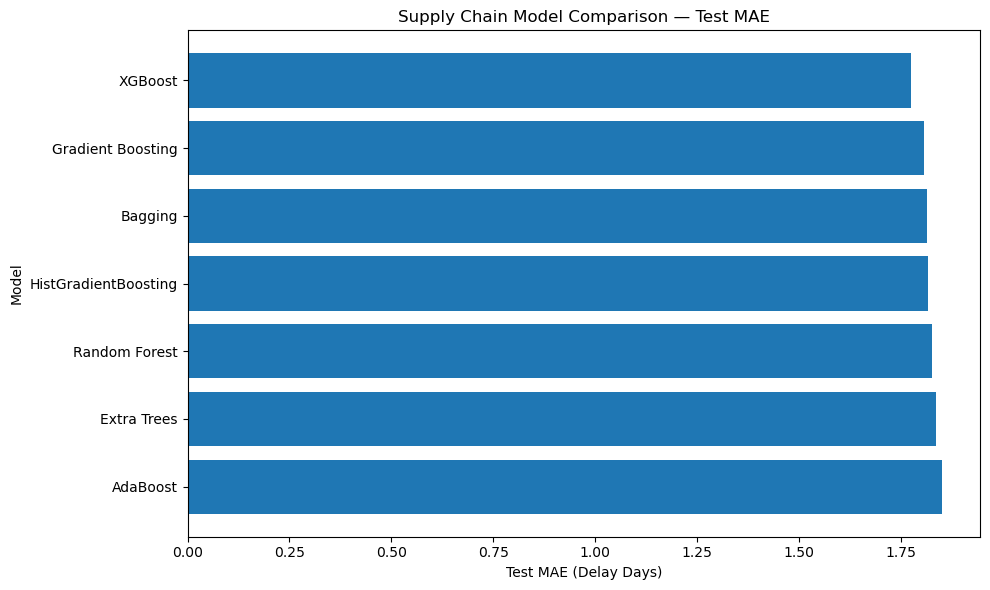

In [59]:
plot_df = results_df.sort_values(
    "Test MAE",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Model"],
    plot_df["Test MAE"],
)

plt.xlabel("Test MAE (Delay Days)")
plt.ylabel("Model")
plt.title("Supply Chain Model Comparison — Test MAE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 25. Test R² by Model

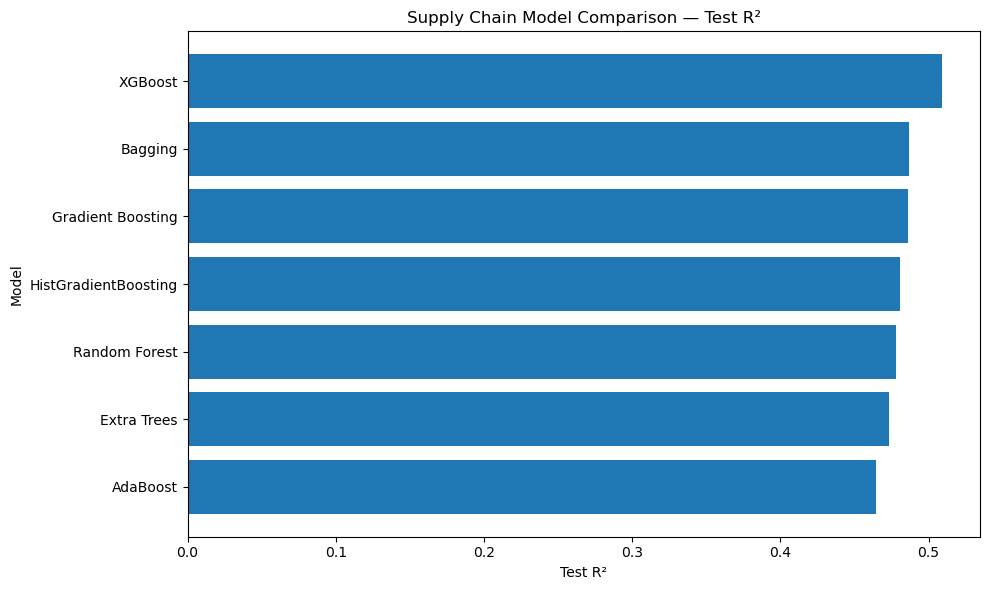

In [61]:
plot_df = results_df.sort_values(
    "Test R²",
    ascending=False,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Model"],
    plot_df["Test R²"],
)

plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Supply Chain Model Comparison — Test R²")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 26. Train R² vs Test R²

This plot helps identify overfitting.

If a model has extremely high training R² but much lower test R², it may be memorizing historical data instead of generalizing.


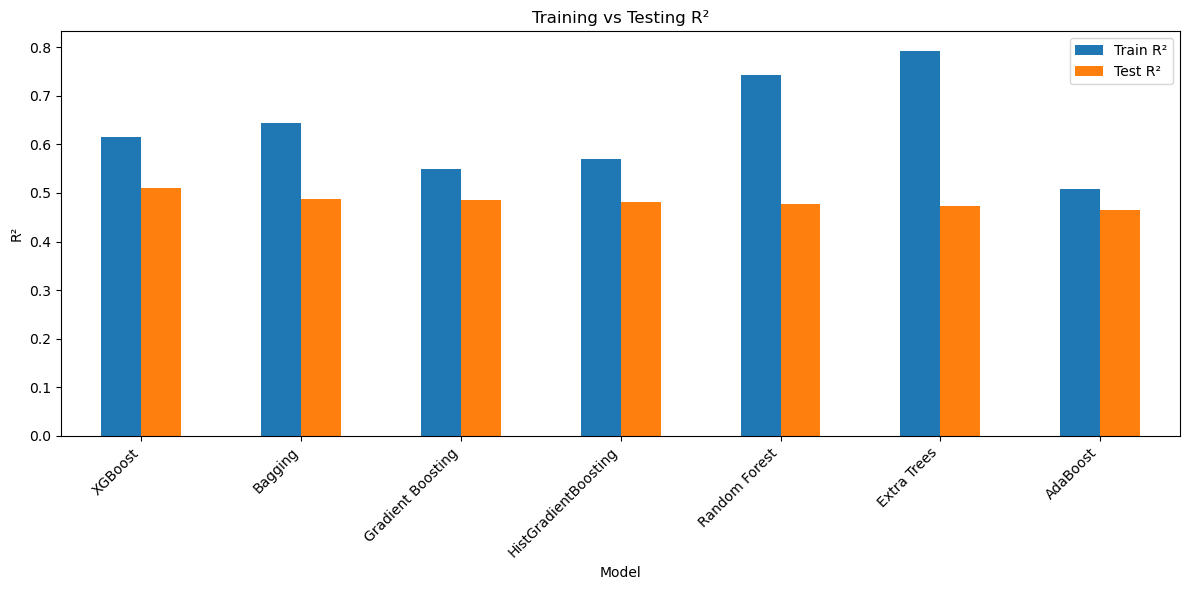

In [63]:
comparison_plot = results_df.set_index("Model")[
    ["Train R²", "Test R²"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("R²")
plt.title("Training vs Testing R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 27. Actual vs Predicted — Best Model

Points close to the diagonal line indicate good predictions.


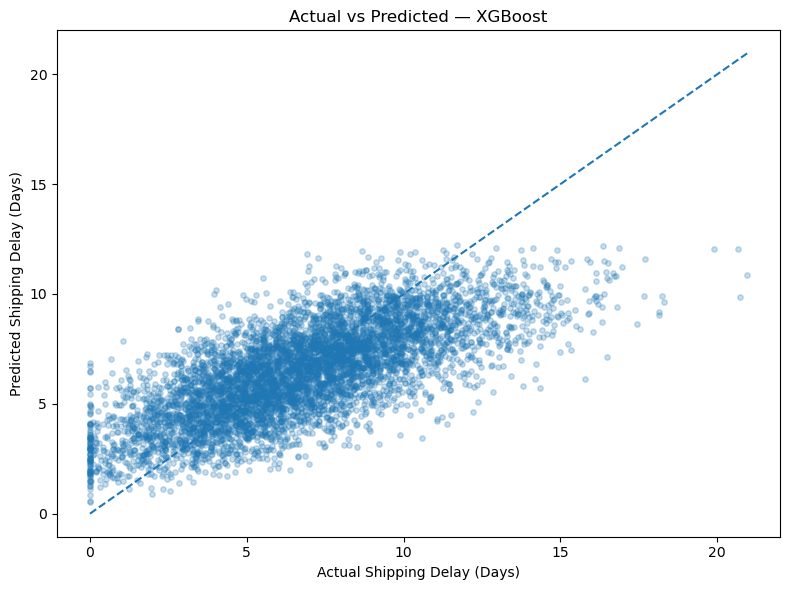

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.25,
    s=15,
)

low = min(
    y_test.min(),
    best_predictions.min(),
)

high = max(
    y_test.max(),
    best_predictions.max(),
)

plt.plot(
    [low, high],
    [low, high],
    linestyle="--",
)

plt.xlabel("Actual Shipping Delay (Days)")
plt.ylabel("Predicted Shipping Delay (Days)")
plt.title(f"Actual vs Predicted — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()


## 28. Residual Analysis — Best Model

Residual:

```text
Actual Delay - Predicted Delay
```

A good model should have residuals distributed around zero without a strong visible pattern.


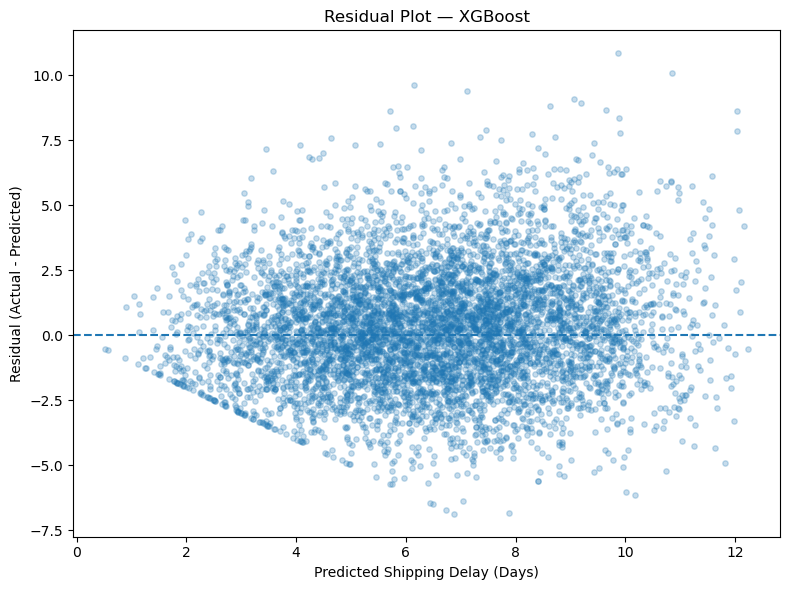

Average residual: 0.3097


In [67]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.25,
    s=15,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted Shipping Delay (Days)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

print("Average residual:", round(residuals.mean(), 4))


# PART F — Feature Importance

## 29. Extract Feature Names

After one-hot encoding, categorical variables produce new columns. We retrieve the final transformed feature names before interpreting importance.


In [69]:
best_preprocessor = best_model.named_steps["preprocessor"]

feature_names = best_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)


Number of transformed features: 18
['trade_volume_tonnes' 'freight_cost_per_tonne'
 'container_availability_index' 'port_congestion_index' 'fuel_cost_index'
 'commodity_stress_index' 'weather_disruption_score'
 'geopolitical_risk_score' 'distance_km' 'estimated_transit_days' 'month'
 'shipping_method_Rail' 'shipping_method_Road' 'shipping_method_Sea'
 'trade_route_type_Consumer Goods' 'trade_route_type_Energy'
 'trade_route_type_Manufacturing' 'trade_route_type_Technology']


## 30. Feature Importance for the Best Model

Many tree-based ensemble models expose `feature_importances_`.

If the winning model supports it, we show the top drivers of predicted shipping delays.

If it does not, this cell explains that instead of failing.


,Feature,Importance
7,geopolitical_risk_score,0.3248
3,port_congestion_index,0.1566
2,container_availability_index,0.1430
6,weather_disruption_score,0.1418
17,trade_route_type_Technology,0.0286
12,shipping_method_Road,0.0212
0,trade_volume_tonnes,0.0209
13,shipping_method_Sea,0.0175
1,freight_cost_per_tonne,0.0171
8,distance_km,0.0156


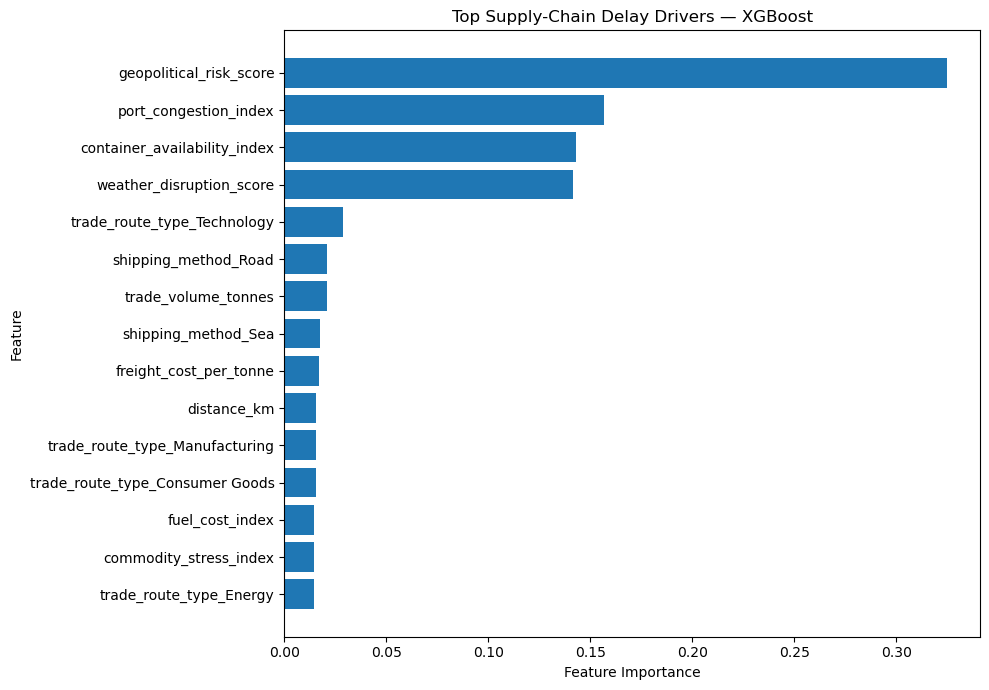

In [71]:
best_estimator = best_model.named_steps["model"]

if hasattr(best_estimator, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": best_estimator.feature_importances_,
        }
    ).sort_values(
        "Importance",
        ascending=False,
    )

    display(importance_df.head(15))

    top_importance = importance_df.head(15).sort_values(
        "Importance",
        ascending=True,
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_importance["Feature"],
        top_importance["Importance"],
    )
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top Supply-Chain Delay Drivers — {BEST_MODEL_NAME}"
    )
    plt.tight_layout()
    plt.show()

else:
    print(
        BEST_MODEL_NAME,
        "does not expose feature_importances_ directly."
    )


# PART G — Business-Level Prediction Output

## 31. Create a Results Table for the Future Test Period


In [73]:
prediction_results = pd.DataFrame(
    {
        "date": test_dates.to_numpy(),
        "actual_shipping_delay_days": y_test.to_numpy(),
        "predicted_shipping_delay_days": best_predictions,
    }
)

prediction_results["absolute_error_days"] = np.abs(
    prediction_results["actual_shipping_delay_days"]
    - prediction_results["predicted_shipping_delay_days"]
)

display(prediction_results.head(20))


,date,actual_shipping_delay_days,predicted_shipping_delay_days,absolute_error_days
0,2024-08-04,8.1500,4.5841,3.5659
1,2024-08-04,4.7300,3.9581,0.7719
2,2024-08-04,7.6000,4.7203,2.8797
3,2024-08-04,5.7600,6.3404,0.5804
4,2024-08-04,5.8000,3.3567,2.4433
5,2024-08-04,6.8900,6.9307,0.0407
6,2024-08-04,10.0100,9.5269,0.4831
7,2024-08-04,5.8700,4.2531,1.6169
8,2024-08-04,6.8100,4.4024,2.4076
9,2024-08-04,12.4700,10.8661,1.6039


## 32. Add Simple Delay-Risk Categories

This is not used to train the regression model.

It is only a business-friendly layer placed on top of the predicted number of delay days.

You can later change these thresholds to match your application's business rules.


In [75]:
def delay_risk_category(predicted_days):
    if predicted_days < 2:
        return "Low Risk"
    elif predicted_days < 5:
        return "Medium Risk"
    else:
        return "High Risk"


prediction_results["predicted_risk_level"] = (
    prediction_results["predicted_shipping_delay_days"]
    .apply(delay_risk_category)
)

display(prediction_results.head(20))


,date,actual_shipping_delay_days,predicted_shipping_delay_days,absolute_error_days,predicted_risk_level
0,2024-08-04,8.1500,4.5841,3.5659,Medium Risk
1,2024-08-04,4.7300,3.9581,0.7719,Medium Risk
2,2024-08-04,7.6000,4.7203,2.8797,Medium Risk
3,2024-08-04,5.7600,6.3404,0.5804,High Risk
4,2024-08-04,5.8000,3.3567,2.4433,Medium Risk
5,2024-08-04,6.8900,6.9307,0.0407,High Risk
6,2024-08-04,10.0100,9.5269,0.4831,High Risk
7,2024-08-04,5.8700,4.2531,1.6169,Medium Risk
8,2024-08-04,6.8100,4.4024,2.4076,Medium Risk
9,2024-08-04,12.4700,10.8661,1.6039,High Risk


## 33. Example: Routes With the Highest Predicted Delay

This is useful for a dashboard or risk-monitoring application because operations teams can prioritize the routes expected to have the largest delays.


In [77]:
highest_risk_predictions = (
    prediction_results
    .sort_values(
        "predicted_shipping_delay_days",
        ascending=False,
    )
    .head(20)
)

display(highest_risk_predictions)


,date,actual_shipping_delay_days,predicted_shipping_delay_days,absolute_error_days,predicted_risk_level
911,2024-12-15,11.7100,12.2327,0.5227,High Risk
2875,2025-09-14,16.3500,12.1668,4.1832,High Risk
5349,2026-08-23,14.1345,12.1069,2.0276,High Risk
5947,2026-11-15,12.9600,12.0825,0.8775,High Risk
5372,2026-08-30,16.8750,12.0707,4.8043,High Risk
5465,2026-09-13,20.6685,12.0431,8.6254,High Risk
5049,2026-07-12,19.8855,12.0341,7.8514,High Risk
1658,2025-03-23,13.7300,12.0105,1.7195,High Risk
1125,2025-01-12,11.2600,11.9937,0.7337,High Risk
5246,2026-08-09,14.9040,11.9807,2.9233,High Risk


# PART H — Save Results

## 34. Save Model Comparison and Predictions

These CSV files can later be used by your Streamlit dashboard.


In [79]:
OUTPUT_DIRECTORY = Path.cwd() / "model_outputs"
OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

comparison_path = (
    OUTPUT_DIRECTORY
    / "ensemble_model_comparison.csv"
)

predictions_path = (
    OUTPUT_DIRECTORY
    / "best_model_shipping_delay_predictions.csv"
)

results_df.to_csv(
    comparison_path,
    index=False,
)

prediction_results.to_csv(
    predictions_path,
    index=False,
)

print("Saved comparison to:", comparison_path.resolve())
print("Saved predictions to:", predictions_path.resolve())


Saved comparison to: C:\Users\bunny\Downloads\model_outputs\ensemble_model_comparison.csv
Saved predictions to: C:\Users\bunny\Downloads\model_outputs\best_model_shipping_delay_predictions.csv


# How to Interpret the Final Result

After running the notebook, focus first on the **test-set metrics**.

### Stronger model
A stronger model generally has:

- lower **Test MAE**
- lower **Test RMSE**
- higher **Test R²**
- a reasonably small gap between Train R² and Test R²

### Example interpretation

Suppose the final table shows:

| Model | Test MAE | Test RMSE | Test R² |
|---|---:|---:|---:|
| Decision Tree | 2.10 | 3.00 | 0.70 |
| Random Forest | 1.50 | 2.20 | 0.84 |
| XGBoost | 1.25 | 1.90 | 0.89 |

Then XGBoost would be the strongest model among those tested because it has the lowest error and highest test R².

Do **not** automatically choose the model with the highest Train R². The goal is to predict new/future supply-chain records.


# Bagging vs Boosting — Easy Interview Explanation

### Bagging
> Bagging trains multiple models independently on different samples of the training data and combines their predictions. Its main goal is to reduce variance and make predictions more stable.

### Random Forest
> Random Forest is an advanced bagging approach that trains many Decision Trees and also randomly samples features when creating splits. This reduces correlation between the trees.

### Boosting
> Boosting trains models sequentially. Each new weak learner focuses on improving the errors made by the previous learners.

### Gradient Boosting
> Gradient Boosting repeatedly fits new trees to the residual errors produced by the current ensemble.

### XGBoost
> XGBoost is an optimized gradient-boosting implementation with regularization and efficient training controls that often works very well for structured tabular data.

### LightGBM
> LightGBM is an efficient gradient-boosting framework that uses histogram-based splitting and leaf-wise growth.

### CatBoost
> CatBoost is another gradient-boosting framework designed for strong performance on structured data and categorical features.


# Project Explanation for Interview

> In my AI Supply Chain Risk Intelligence project, I used historical operational and environmental data to predict shipping delay days. After establishing a Decision Tree baseline, I extended the modeling to ensemble methods. I implemented bagging models such as Bagging Regressor, Random Forest, and Extra Trees, and boosting models including AdaBoost, Gradient Boosting, Histogram Gradient Boosting, XGBoost, LightGBM, and CatBoost. I kept the same features, preprocessing, and chronological 80/20 train-test split for every model so the comparison was fair. I evaluated the models using MAE, RMSE, R², and the train-test generalization gap. The final pipeline automatically ranks the models using future-period test RMSE, selects the best-performing model, analyzes residuals and feature importance, and produces business-level delay-risk predictions that can be integrated into the Streamlit risk dashboard.


# Final Learning Summary

### Decision Tree
One tree. Easy to explain, but can overfit.

### Bagging
Many independent learners + averaging → mainly reduces variance.

### Random Forest
Bagging + randomized feature selection → stronger diversity among trees.

### Extra Trees
Even more randomized tree construction → often fast and robust.

### AdaBoost
Sequential learners give more attention to difficult observations.

### Gradient Boosting
Sequential trees correct residual errors.

### HistGradientBoosting
Histogram-based boosting optimized for efficient tabular learning.

### XGBoost / LightGBM / CatBoost
Modern optimized gradient-boosting implementations frequently used for structured/tabular machine-learning problems.

### Most important project rule
Compare models on **future/unseen test data**, not on training accuracy.
